<a href="https://colab.research.google.com/github/joanby/matematicas-ml/blob/master/4_calculus_ii.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo II: Derivadas parciales e integrales

Esta clase, *Cálculo II: Derivadas Parciales e Integrales*, se basa en el cálculo de derivadas de una sola variable para introducir los gradientes y el cálculo integral. Los gradientes de aprendizaje, facilitados por el cálculo de derivadas parciales, son la base del entrenamiento con datos de la mayoría de los algoritmos de aprendizaje automático, es decir, el descenso de gradiente estocástico (SGD). Combinado con el principio de la regla de la cadena (también tratado en esta clase), el SGD permite al algoritmo de retropropagación entrenar redes neuronales profundas.

El cálculo integral, por su parte, resulta útil para innumerables tareas relacionadas con el aprendizaje automático, como encontrar el área bajo la denominada «curva ROC», una métrica predominante para evaluar modelos de clasificación. El contenido de esta clase es fundamental para otras clases de la serie *Fundamentos del aprendizaje automático*, especialmente *Probabilidad y teoría de la información* y *Optimización*.

En el transcurso del estudio de este tema, usted:

* Desarrollar una comprensión de lo que está pasando bajo el capó de los algoritmos de aprendizaje automático, incluidos los utilizados para el aprendizaje profundo.
* Ser capaz de comprender los detalles de la derivada parcial, cálculo multivariante que es común en los documentos de aprendizaje automático, así como muchos en otros temas que subyacen ML, incluyendo la teoría de la información y algoritmos de optimización.
* Utilizar el cálculo integral para determinar el área bajo cualquier curva dada, una tarea recurrente en ML aplicada, por ejemplo, para evaluar el rendimiento del modelo mediante el cálculo de la métrica ROC AUC.

**Tenga en cuenta que este cuaderno Jupyter no está diseñado para funcionar por sí solo. Es el código que acompaña a una clase o a los vídeos de la serie [Machine Learning Foundations](https://github.com/jonkrohn/ML-foundations) de Jon Krohn, que ofrecen detalles sobre lo siguiente:**

*Segmento 1: Repaso de Cálculo Introductorio*.

* El método Delta
* Diferenciación con reglas
* AutoDiff: Diferenciación Automática


*Segmento 2: Gradientes de Aprendizaje Automático*

* Derivadas Parciales de Funciones Multivariantes
* La regla de la cadena de derivadas parciales
* Coste Cuadrático
* Gradientes
* Gradient Descent
* Backpropagation
* Derivadas parciales de orden superior


*Segmento 3: Integrales*

* Clasificación binaria
* La matriz de confusión
* La curva ROC (Receiver-Operating Characteristic)
* Cálculo manual de integrales
* Integración numérica con Python
* Hallar el área bajo la curva ROC
* Recursos para profundizar en el cálculo

## Resumen: Lo Más Importante de Este Notebook

Una chuleta rápida con lo esencial, para tener una vista de conjunto antes de empezar (o repasar después sin releer todo el notebook).

### Derivadas parciales y el gradiente

* Una **derivada parcial** deriva una función de varias variables respecto a **una** de ellas, tratando las demás como constantes: $\frac{\partial z}{\partial x}$.
* El **gradiente** ($\nabla$) junta todas las derivadas parciales de una función en un vector — y apunta en la dirección en la que la función crece más rápido.
* Ejemplo: con $z=x^2-y^2$, $\frac{\partial z}{\partial x}=2x$ y $\frac{\partial z}{\partial y}=-2y$ (cada término «desaparece» al derivar respecto a la otra variable, por ser tratado como constante).

### Coste, descenso de gradiente y retropropagación

* La **función de coste** ($C=(\hat{y}-y)^2$) mide el error de un modelo, y depende de **todos** sus parámetros a la vez.
* **Descenso de gradiente**: mover cada parámetro en la dirección **opuesta** a su derivada parcial en $C$ ($w_{\text{nuevo}}=w_{\text{viejo}}-\eta\cdot\frac{\partial C}{\partial w}$) reduce el error paso a paso — así «aprende» un modelo.
* **Retropropagación**: aplicar la regla de la cadena (de *Cálculo I*) a derivadas parciales, capa por capa desde la salida hacia la entrada, calcula el gradiente completo de una red neuronal en una sola pasada.

**Ejemplo real** (red de 2 capas: $h=\sigma(w_1x+b_1)$, $\hat{y}=w_2h+b_2$): una sola llamada a `.backward()` da los 4 gradientes a la vez — incluido $\partial L/\partial w_1\approx-0{,}9478$, el de la capa más alejada de la salida, calculado encadenando 3 derivadas parciales ($\partial L/\partial\hat{y}\cdot\partial\hat{y}/\partial h\cdot\partial h/\partial w_1$) — la regla de la cadena en acción, exactamente igual con 2 capas que con 200.

Como grafo (igual que con la regresión lineal, pero con una capa extra en medio):

```
Capa oculta:
x ──────┐
        ×──┐
w1 ─────┘  │
           +──► pre₁ ──► σ ──► h
b1 ────────┘

Capa de salida:
h ──────┐
        ×──┐
w2 ─────┘  │
           +──► ŷ
b2 ────────┘

Coste:
ŷ ──────┐
        −──► (ŷ−y) ──► ^2 ──► L
y ──────┘
```

In [1]:
w1 = torch.tensor(0.5, requires_grad=True)   # peso de la capa oculta
b1 = torch.tensor(0.0, requires_grad=True)   # sesgo de la capa oculta
w2 = torch.tensor(1.5, requires_grad=True)   # peso de la capa de salida
b2 = torch.tensor(0.1, requires_grad=True)   # sesgo de la capa de salida
x = torch.tensor(2.0)                        # dato de entrada
y_true = torch.tensor(2.0)                   # valor real

h = torch.sigmoid(w1 * x + b1)   # forward pass: capa oculta (no lineal)
y_pred = w2 * h + b2             # forward pass: capa de salida
loss = (y_pred - y_true)**2      # forward pass: coste

loss.backward()                  # backward pass: los 4 gradientes a la vez

print(f"dL/dw1 = {w1.grad.item():.4f}  (capa oculta)")
print(f"dL/db1 = {b1.grad.item():.4f}  (capa oculta)")
print(f"dL/dw2 = {w2.grad.item():.4f}  (capa de salida)")
print(f"dL/db2 = {b2.grad.item():.4f}  (capa de salida)")


dL/dw1 = -0.9478  (capa oculta)
dL/db1 = -0.4739  (capa oculta)
dL/dw2 = -1.1747  (capa de salida)
dL/db2 = -1.6068  (capa de salida)


### Integrales

* Una **integral** calcula el área bajo una curva — la operación inversa de la derivada.
* Se puede resolver a mano con la **antiderivada** (la regla de la potencia «al revés»: sumar 1 al exponente y dividir por él), o numéricamente con `scipy.integrate.quad` (dividiendo el área en franjas estrechas y sumándolas, como el método delta pero para áreas).
* Ejemplo: $\int_1^2 \frac{x}{2}dx = 0{,}75$; $\int_3^4 2x\,dx = 7$.

### Clasificación binaria y la curva ROC

* En un problema de sí/no, la **matriz de confusión** recoge los 4 resultados posibles al comparar predicción y realidad: verdadero/falso positivo/negativo.
* La **curva ROC** representa la tasa de verdaderos positivos frente a la de falsos positivos, según se mueve el umbral de decisión.
* El **AUC** (área bajo esa curva, calculada con una integral) resume el rendimiento del clasificador en un solo número: $1$ = perfecto, $0{,}5$ = adivinar al azar.

**Ejemplo real**: con la curva ROC sencilla de 5 puntos del notebook, el área da $0{,}75$ — bastante mejor que adivinar al azar (diagonal gris)(0.75 significa: si coges UN caso positivo al azar y UN caso negativo al azar (una pareja), hay un 75% de probabilidad de que el modelo le dé mayor puntuación/probabilidad al positivo que al negativo.), aunque lejos de ser un clasificador perfecto:

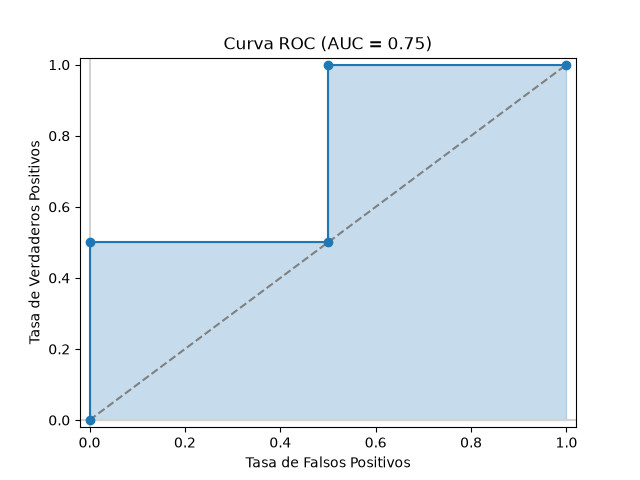

## Segmento 1: Repaso de Cálculo Introductorio

Revisar el notebook de [*Regresión en Pytorch* ](https://github.com/joanby/matematicas-ml/blob/master/notebooks/regression-in-pytorch.ipynb).

Antes de avanzar, un resumen relámpago de *Cálculo I* — todo lo que sigue se construye sobre esto:

* El **método delta**: acercar un punto $Q$ a $P$ para hallar la pendiente exacta de una curva en $P$ — eso es la derivada.
* Las **reglas de derivación** (potencia, suma, producto, cociente, y sobre todo la **regla de la cadena**): permiten derivar sin repetir el método delta cada vez.
* El **autodiff** (PyTorch/TensorFlow): calcula derivadas automáticamente construyendo un grafo de las operaciones y aplicando la regla de la cadena hacia atrás.

Todo esto se aplicaba a funciones de **una sola variable**, $f(x)$. Un modelo de Machine Learning real tiene muchos parámetros a la vez — así que el siguiente paso natural es extender todo esto a funciones de **varias variables**, que es justo el tema de este notebook.

## Segmento 2: Gradientes aplicados al Machine Learning

Un modelo no se entrena ajustando un único número — se ajustan **muchos parámetros a la vez** (todos los pesos de una red neuronal, por ejemplo). Para eso necesitamos derivar funciones de varias variables, y saber combinar todas esas derivadas en un único objeto: el **gradiente**. Este segmento es, literalmente, las matemáticas que hacen posible el entrenamiento de un modelo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import math # para la constante PI

### Derivadas parciales de funciones multivariantes

Definimos la función $f(x, y)$ para $z = x^2 - y^2$:

Una **derivada parcial** es la derivada de una función de varias variables, pero calculada tratando **todas las demás variables como si fueran números fijos** — solo dejamos que una varíe cada vez. Se escribe con $\partial$ (una «d» redondeada) en vez de $d$, precisamente para distinguirla de la derivada de una sola variable que ya conoces: $\frac{\partial z}{\partial x}$ se lee «la derivada de $z$ respecto a $x$, manteniendo las demás variables constantes».

In [ ]:
def f(my_x, my_y):
    return my_x**2 - my_y**2

Esta función tiene forma de «silla de montar»: sube en una dirección ($x$) y baja en la otra ($y$) al mismo tiempo — vamos a comprobarlo mirando cada dirección por separado.

Traza $z$ con respecto a $x$ variando $x$...

In [ ]:
xs = np.linspace(-3, 3, 1000)

...mientras mantenemos $y$ constante (por ejemplo en $y = 0$):

In [ ]:
zs_wrt_x = f(xs, 0)

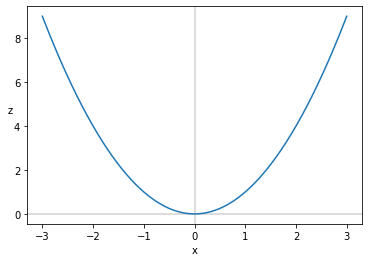

In [ ]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')

plt.xlabel('x')
plt.ylabel('z', rotation=0)
_ = ax.plot(xs, zs_wrt_x)

Para determinar la pendiente de $z$ respecto a $x$ en un punto dado de la curva, podemos utilizar la derivada parcial de las diapositivas: $$ \frac{\partial z}{\partial x} = 2x$$

Fíjate en que $\frac{\partial z}{\partial x}=2x$ es exactamente la regla de la potencia de *Cálculo I* aplicada a $x^2$ — el término $-y^2$ simplemente **desaparece** al derivar respecto a $x$, porque estamos tratando $y$ como una constante, y la derivada de una constante es 0.

In [ ]:
def delz_delx(my_x, my_y): # y no es relevante para *esta* derivada parcial; a menudo lo será
    return 2*my_x

In [ ]:
x_samples = [-2, -1, 0, 1, 2]

In [ ]:
colors = ['red', 'orange', 'green', 'blue', 'purple']

In [ ]:
def point_and_tangent_wrt_x(my_xs, my_x, my_y, my_f, fprime, col):

    my_z = my_f(my_x, my_y) # z = f(x, y)
    plt.scatter(my_x, my_z, c=col, zorder=3)

    tangent_m = fprime(my_x, my_y) # La pendiente es la derivada parcial de f(x, y) con respecto a x
    tangent_b = my_z - tangent_m*my_x # La recta es z=mx+b, por tanto b=z-mx
    tangent_line = tangent_m*my_xs + tangent_b

    plt.plot(my_xs, tangent_line, c=col,
             linestyle='dashed', linewidth=0.7, zorder=3)

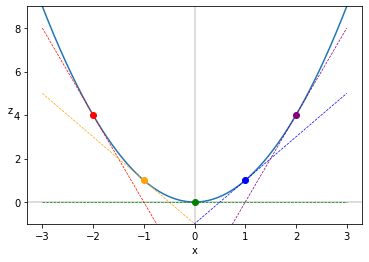

In [ ]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')

for i, x in enumerate(x_samples):
    point_and_tangent_wrt_x(xs, x, 0, f, delz_delx, colors[i])

plt.ylim(-1, 9)
plt.xlabel('x')
plt.ylabel('z', rotation=0)
_ = ax.plot(xs, zs_wrt_x)

Demostrando así visualmente $\frac{\partial z}{\partial x} = 2x$.

Es decir, la pendiente de $z$ a lo largo del eje $x$ es *dos veces* el valor de $x$.

**Volver a las slides.**

Ahora vamos a representar $z$ con respecto a $y$ variando $y$...

In [ ]:
ys = np.linspace(-3, 3, 1000)

...mientras mantenemos $x$ constantw (es decir, por ejemplo $x$ = 0):

In [ ]:
zs_wrt_y = f(0, ys)

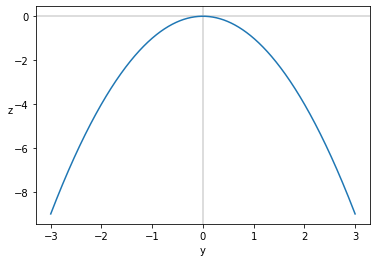

In [ ]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')

plt.xlabel('y')
plt.ylabel('z', rotation=0)
_ = ax.plot(ys, zs_wrt_y)

Como en las diapositivas, la derivada parcial de $z$ respecto a $y$ resulta ser independiente de $x$ (igual que antes observamos que $x$ es independiente de $y$), por lo que mientras $z$ varía en función tanto de $x$ como de $y$, la pendiente de $z$ respecto a $y$ es la misma sea cual sea $x$: $$ \frac{\partial z}{\partial y} = -2y $$

Aquí ocurre lo simétrico: al derivar respecto a $y$, el término $x^2$ se trata como constante y desaparece, dejando solo la derivada de $-y^2$.

Así, por ejemplo, mantener $x$ constante en 2 en lugar de 0 aumenta $z$, pero no tiene ningún impacto en la pendiente de $z$ respecto a $y$:

In [ ]:
zs_wrt_y = f(2, ys)

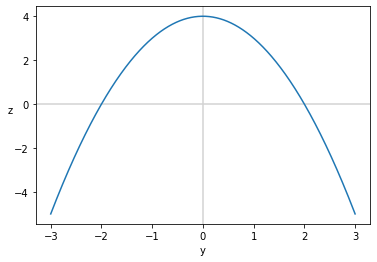

In [ ]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')

plt.xlabel('y')
plt.ylabel('z', rotation=0)
_ = ax.plot(ys, zs_wrt_y)

In [ ]:
def delz_dely(my_x, my_y):
    return -2*my_y

In [ ]:
y_samples = [-2, -1, 0, 1, 2]

In [ ]:
def point_and_tangent_wrt_y(my_ys, my_x, my_y, my_f, fprime, col): # cambiamos my_xs por my_ys

    my_z = my_f(my_x, my_y)
    plt.scatter(my_y, my_z, c=col, zorder=3) # cambiamos my_x por my_y

    tangent_m = fprime(my_x, my_y)
    tangent_b = my_z - tangent_m*my_y # cambiamos my_x por my_y
    tangent_line = tangent_m*my_ys + tangent_b # cambiamos my_xs por my_ys

    plt.plot(my_ys, tangent_line, c=col,
             linestyle='dashed', linewidth=0.7, zorder=3) # cambiamos my_xs por my_ys

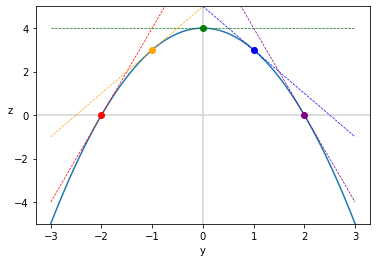

In [ ]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')

for i, y in enumerate(y_samples):
    point_and_tangent_wrt_y(ys, 2, y, f, delz_dely, colors[i])

plt.ylim(-5, 5)
plt.xlabel('y')
plt.ylabel('z', rotation=0)
_ = ax.plot(xs, zs_wrt_y)

Demostrando así visualmente $\frac{\partial z}{\partial y} = -2y$.

Es decir, la pendiente de $z$ a lo largo del eje $y$ es *el doble* del valor de $y$ *e invertida*, lo que da lugar a que la curva parabólica se abra hacia abajo.

**Ejercicios**: Usa lápiz y papel para determinar:

* El valor de $z$,
* La pendiente de $z$ con respecto a $x$,
* Y la pendiente de $z$ con respecto a $y$

...en los puntos donde:

1. $x = 3, y = 0$
2. $x = 2, y = 3$
3. $x = -2, y = -3$

Determinar derivadas parciales a mano utilizando reglas es útil para entender cómo funciona el cálculo. En la práctica, sin embargo, la autodiferenciación nos permite hacerlo más fácilmente (sobre todo si hay un gran número de variables). Por ejemplo, utilicemos la biblioteca de diferenciación automática PyTorch para calcular la pendiente de $z$ con respecto a $x$ e $y$ en un punto cualquiera $(x, y, z)$:

In [ ]:
x = torch.tensor(0.).requires_grad_()
x

tensor(0., requires_grad=True)

In [ ]:
y = torch.tensor(0.).requires_grad_()
y

tensor(0., requires_grad=True)

In [ ]:
z = f(x, y) # Forward pass
z

tensor(0., grad_fn=<SubBackward0>)

In [ ]:
z.backward() # Autodiff

Como ya sabíamos por nuestros ejercicios anteriores, la pendiente del punto (0, 0, 0) es cero con respecto a los ejes $x$ e $y$:

### El gradiente: todas las derivadas parciales juntas

Cuando juntamos **todas** las derivadas parciales de una función en un solo vector, obtenemos el **gradiente**, denotado $\nabla$ (nabla):

$$ \nabla z = \left[\frac{\partial z}{\partial x},\ \frac{\partial z}{\partial y}\right] $$

El gradiente tiene una propiedad clave: **apunta en la dirección en la que la función crece más rápido**. Por eso, para *minimizar* una función (como el error de un modelo), basta con movernos en la dirección **opuesta** al gradiente — esa es, literalmente, la idea completa del **descenso de gradiente**, que veremos en detalle un poco más abajo.

In [ ]:
x.grad

tensor(0.)

In [ ]:
y.grad

tensor(-0.)

**Ejercicio**: Repite los ejercicios más recientes de lápiz y papel usando PyTorch (o TensorFlow, si lo prefieres).

**Volver a las slides aquí.**

### Derivadas parciales del volumen de un cilindro

El volumen de un cilindro se describe por $v = \pi r^2 l$ donde:

* $r$ es el radio del cilindro
* $l$ es su altura

Vamos a practicar con una función de varias variables algo más realista — el volumen de un cilindro depende de dos cantidades independientes, su radio y su altura — antes de dar el salto a funciones de coste con muchísimos parámetros.

In [ ]:
def cylinder_vol(my_r, my_l):
    return math.pi * my_r**2 * my_l

In [ ]:
# Si por ejemplo el radio es de 3 metros...
r = torch.tensor(3.).requires_grad_()
r

tensor(3., requires_grad=True)

In [ ]:
# ...y la altura es de 5 metros:
l = torch.tensor(5.).requires_grad_()
l

tensor(5., requires_grad=True)

In [ ]:
# Entonces el volumen sería de 141.4 metros cúbicos:
v = cylinder_vol(r, l)
v

tensor(141.3717, grad_fn=<MulBackward0>)

In [ ]:
v.backward()

In [ ]:
l.grad

tensor(28.2743)

Y como hemos visto en las transparencias: $$\frac{\partial v}{\partial l} = \pi r^2$$

In [ ]:
math.pi * 3**2

28.274333882308138

Esto significa que con $r = 3$, un cambio en $l$ de una unidad corresponde a un cambio en $v$ de 28,27$\text{m}^3$. Podemos demostrarlo nosotros mismos:

In [ ]:
cylinder_vol(3, 6)

169.64600329384882

In [ ]:
cylinder_vol(3, 6) - cylinder_vol(3, 5)

28.274333882308127

In [ ]:
cylinder_vol(3, 7) - cylinder_vol(3, 6)

28.274333882308156

**Volver a las slides aquí.**

Para cambios en $v$ con respecto a $r$ tenemos lo siguiente de las diapositivas: $$\frac{\partial v}{\partial r} = 2 \pi r l$$

In [ ]:
r.grad

tensor(94.2478)

In [ ]:
2 * math.pi * 3 * 5

94.24777960769379

$r$ está incluida en la derivada parcial por lo que su ajuste afecta a la escala de su impacto sobre $v$. Aunque es nuestro primer ejemplo en este cuaderno, es típico en cálculo que la derivada sólo se aplique a un $\Delta r$ infinitesimalmente pequeño. Cuanto más pequeño sea $\Delta r$, más se acercará a la verdadera $\frac{\partial v}{\partial r}$. Por ejemplo, en $\Delta r = 1 \times 10^{-6}$:

Esto es exactamente el **método delta** de *Cálculo I*, aplicado ahora a una sola variable de una función multivariable (mientras la otra, $l$, se mantiene fija) — la misma idea de siempre, solo que ahora conviviendo con más variables alrededor.

In [ ]:
delta = 1e-6

In [ ]:
(cylinder_vol(3 + delta, 5) - cylinder_vol(3, 5)) / delta # Dividiendo por delta, restaura la escala

94.24779531741478

**Volver a las slides aquí.**

### Coste, Gradientes y Descenso de Gradiente

Unamos ya todas las piezas con el caso que de verdad importa en Machine Learning: ajustar los parámetros de un modelo.

**Coste cuadrático**: para medir qué tan mal predice un modelo, se usa una **función de coste** — la que ya viste en la regresión de precios de casas, el error cuadrático $C=(\hat{y}-y)^2$ (o su media sobre todos los ejemplos de entrenamiento). $\hat{y}$ es la predicción del modelo, que depende de sus parámetros (pesos $w_1,\dots,w_n$ y sesgo $b$) — así que $C$ es, en el fondo, una función de **todos esos parámetros a la vez**: $C(w_1,\dots,w_n,b)$.

**El gradiente del coste**, $\nabla C = \left[\frac{\partial C}{\partial w_1},\dots,\frac{\partial C}{\partial w_n},\frac{\partial C}{\partial b}\right]$, es un vector con una derivada parcial por cada parámetro del modelo — nos dice, para cada uno, en qué dirección aumentaría el error si lo tocásemos un poquito.

**Descenso de gradiente**: como el gradiente apunta hacia donde el coste *aumenta* más rápido, para reducirlo nos movemos en la dirección contraria:

$$ w_{\text{nuevo}} = w_{\text{viejo}} - \eta \cdot \frac{\partial C}{\partial w} $$

donde $\eta$ (*eta*) es la **tasa de aprendizaje** (*learning rate*): cuánto nos movemos en cada paso. Repitiendo esta actualización miles de veces —calcular el gradiente, dar un paso pequeño en su dirección opuesta— el coste va bajando poco a poco: así es como «aprende» un modelo.

**La regla de la cadena para derivadas parciales, y la retropropagación**: en una red neuronal con varias capas, el coste final depende de los pesos de la *primera* capa a través de una larga cadena de composiciones (la salida de cada capa alimenta a la siguiente). Igual que en *Cálculo I* la regla de la cadena permitía derivar una función compuesta, aquí permite calcular $\frac{\partial C}{\partial w}$ para un peso de una capa cualquiera, multiplicando las derivadas parciales de todas las capas intermedias. Aplicar esta regla de forma sistemática, capa por capa, de la salida hacia la entrada, es exactamente la **retropropagación (*backpropagation*)** — el algoritmo que calcula el gradiente completo de una red en una sola pasada hacia atrás, sin el cual entrenar una red profunda sería inviable.

### De la teoría a una red real: retropropagación en 2 capas

Veámoslo con números, extendiendo el ejemplo de regresión de *Cálculo I* añadiendo una **capa oculta** — lo mínimo que hace falta para que sea una red neuronal «de verdad» (con más de una capa) y no solo una regresión lineal. La red: un dato de entrada $x$ pasa por una neurona oculta (con una función de activación no lineal, $\sigma$, la sigmoide) y luego por una neurona de salida:

$$ h = \sigma(w_1x+b_1) \qquad \hat{y} = w_2h+b_2 \qquad L=(\hat{y}-y)^2 $$

Fíjate en la cadena de composiciones: $L$ depende de $\hat{y}$, que depende de $h$, que depende de $w_1$. Para calcular $\frac{\partial L}{\partial w_1}$ hay que atravesar **dos capas** — exactamente el caso en el que la regla de la cadena (y la retropropagación) se vuelve imprescindible, no solo conveniente.

Como grafo (igual que hicimos con la regresión lineal, pero ahora con una capa extra en medio):

```
Capa oculta:
x ──────┐
        ×──┐
w1 ─────┘  │
           +──► pre₁ ──► σ ──► h
b1 ────────┘

Capa de salida:
h ──────┐
        ×──┐
w2 ─────┘  │
           +──► ŷ
b2 ────────┘

Coste:
ŷ ──────┐
        −──► (ŷ−y) ──► ^2 ──► L
y ──────┘
```

La salida de la capa oculta, $h$, se convierte en la entrada de la capa de salida — exactamente como la salida de una capa alimenta a la siguiente en una red real. Para llegar desde $L$ hasta $w_1$ hay que atravesar **todo el grafo hacia atrás**, pasando por la capa de salida antes de llegar a la oculta — eso es, literalmente, la retropropagación.

In [1]:
x = torch.tensor(2.0)
y_true = torch.tensor(2.0)

w1 = torch.tensor(0.5, requires_grad=True)   # peso de la capa oculta
b1 = torch.tensor(0.0, requires_grad=True)   # sesgo de la capa oculta
w2 = torch.tensor(1.5, requires_grad=True)   # peso de la capa de salida
b2 = torch.tensor(0.1, requires_grad=True)   # sesgo de la capa de salida

h = torch.sigmoid(w1 * x + b1)   # forward pass: capa oculta (no lineal)
y_pred = w2 * h + b2             # forward pass: capa de salida
loss = (y_pred - y_true)**2      # forward pass: coste

loss.backward()                  # backward pass: UNA llamada, y calcula los 4 gradientes a la vez

print(f"h (salida de la capa oculta): {h.item():.4f}")
print(f"Predicción: {y_pred.item():.4f}")
print(f"Error (loss): {loss.item():.4f}")
print(f"dL/dw1 = {w1.grad.item():.4f}  (capa oculta)")
print(f"dL/db1 = {b1.grad.item():.4f}  (capa oculta)")
print(f"dL/dw2 = {w2.grad.item():.4f}  (capa de salida)")
print(f"dL/db2 = {b2.grad.item():.4f}  (capa de salida)")


h (salida de la capa oculta): 0.7311
Predicción: 1.1966
Error (loss): 0.6455
dL/dw1 = -0.9478  (capa oculta)
dL/db1 = -0.4739  (capa oculta)
dL/dw2 = -1.1747  (capa de salida)
dL/db2 = -1.6068  (capa de salida)


Con una única llamada a `.backward()` hemos obtenido los 4 gradientes a la vez — incluido $\frac{\partial L}{\partial w_1}$, el de la capa **más alejada** de la salida. Por si tienes curiosidad, así es exactamente como PyTorch lo calcula por debajo, encadenando derivadas parciales de la salida hacia la entrada (la retropropagación en acción):

$$ \frac{\partial L}{\partial w_1} = \underbrace{\frac{\partial L}{\partial \hat{y}}}_{-1{,}6068} \cdot \underbrace{\frac{\partial \hat{y}}{\partial h}}_{w_2=1{,}5} \cdot \underbrace{\frac{\partial h}{\partial w_1}}_{\sigma'(\cdot)\cdot x \,\approx\, 0{,}3932} \approx -0{,}9478 $$

Tres derivadas parciales, una por cada «eslabón» entre $w_1$ y $L$, multiplicadas entre sí — ni más ni menos que la regla de la cadena. Con miles de capas y millones de pesos, el principio es idéntico; solo cambia la longitud de la cadena que hay que recorrer, y por eso hace falta un algoritmo (retropropagación) en vez de escribirlo a mano como acabamos de hacer aquí.

**Derivadas parciales de orden superior**: igual que una función de una variable se puede derivar dos veces (la segunda derivada mide la *curvatura*), una derivada parcial también se puede volver a derivar. Esto queda fuera del alcance de este notebook, pero es la base de optimizadores más avanzados que el descenso de gradiente básico (como los que usan una aproximación de la curvatura para dar pasos más inteligentes).

Ver los notebooks independientes:

* [Gradiente de regresión de un punto](https://github.com/joanby/matematicas-ml/blob/master/notebooks/single-point-regression-gradient.ipynb)
* [Gradiente de regresión por lotes](https://github.com/joanby/matematicas-ml/blob/master/notebooks/batch-regression-gradient.ipynb)

## Segmento 3: Integrales

Una **integral** calcula el **área bajo una curva** entre dos puntos. Es, en cierto sentido, la operación inversa de la derivada: mientras la derivada mide la pendiente (una tasa de cambio instantánea), la integral **acumula** — suma infinitos «trocitos infinitamente delgados» de área bajo la curva. Por eso el cálculo diferencial y el integral son las dos mitades de la misma disciplina.

En Machine Learning, la aplicación más habitual (y la que veremos aquí) es calcular el área bajo la **curva ROC**, una métrica estándar para evaluar modelos de clasificación.

In [ ]:
from scipy.integrate import quad # "cuadratura" = integración numérica (opuesta a la simbólica)

De las slides: $$ \int_1^2 \frac{x}{2} dx = \frac{3}{4} $$

La notación $\int_1^2 \frac{x}{2}\,dx$ se lee «la integral de $\frac{x}{2}$ entre $x=1$ y $x=2$» — el área bajo la recta $y=\frac{x}{2}$, entre esos dos límites.

**Resolverlo a mano** (aunque en este notebook lo hagamos numéricamente) sigue la regla de la potencia, pero «al revés»: para derivar $x^n$ se multiplica por $n$ y se resta 1 al exponente; para *integrar*, se hace lo contrario — se suma 1 al exponente y se divide por el nuevo exponente. Así, la **antiderivada** de $\frac{x}{2}$ es $F(x)=\frac{x^2}{4}$ (puedes comprobar que $F'(x)=\frac{x}{2}$, volviendo atrás). El área buscada es, simplemente, $F(2)-F(1) = 1 - 0{,}25 = 0{,}75 = \frac{3}{4}$ — coincide con la respuesta de las diapositivas.

In [ ]:
def g(x):
    return x/2

In [ ]:
quad(g, 1, 2)

(0.75, 8.326672684688674e-15)

La segunda salida de `quad` es una estimación del error absoluto de la integral, que en este caso es esencialmente cero.

`quad` usa **integración numérica** (de ahí el nombre, «cuadratura»): en vez de encontrar la antiderivada algebraicamente como acabamos de hacer, aproxima el área dividiéndola en muchísimas franjas estrechas y sumándolas — parecido en espíritu al método delta que usamos para las derivadas, pero para áreas en vez de pendientes. Por eso devuelve dos números: el área estimada, y una estimación de cuánto error de aproximación puede tener.

**Volver a las slides aquí.**

In [ ]:
def h(x):
    return 2*x

Comprobación a mano: la antiderivada de $2x$ es $x^2$, así que $\int_3^4 2x\,dx = 4^2 - 3^2 = 16-9=7$ — coincide con lo que devuelve `quad` más abajo.

In [ ]:
quad(h, 3, 4)

(7.0, 7.771561172376096e-14)

**Volver a las slides aquí.**

### Área bajo la curva ROC

Antes de llegar al área en sí, aclaremos qué es esta curva y por qué importa.

**Clasificación binaria**: un modelo que solo tiene que decidir entre dos opciones (sí/no, spam/no-spam, «¿es un hotdog?»/«no es un hotdog»). En vez de dar directamente «sí» o «no», la mayoría de modelos dan una **probabilidad** (p. ej. 0,82), y se decide «sí» si esa probabilidad supera un **umbral** (normalmente 0,5) — pero ese umbral se puede mover.

**Matriz de confusión**: al comparar las predicciones del modelo con la realidad, solo hay 4 resultados posibles:

| | Real: Sí | Real: No |
|---|---|---|
| **Predicho: Sí** | Verdadero positivo (VP) | Falso positivo (FP) |
| **Predicho: No** | Falso negativo (FN) | Verdadero negativo (VN) |

**La curva ROC** representa, para *cada posible umbral* de decisión, dos tasas calculadas a partir de esa tabla: la **tasa de verdaderos positivos** ($\frac{VP}{VP+FN}$, eje $y$) frente a la **tasa de falsos positivos** ($\frac{FP}{FP+VN}$, eje $x$). Late un umbral distinto en cada punto de la curva, dibujando el «compromiso» entre acertar más positivos y equivocarse menos con los negativos.

**AUC (área bajo la curva ROC)**: resume toda esa curva en un único número entre 0 y 1. $\text{AUC}=1$ es un clasificador perfecto; $\text{AUC}=0{,}5$ es equivalente a adivinar al azar (la diagonal); cuanto más se acerque a 1, mejor separa el modelo las dos clases — y calcular esa área es, precisamente, una **integral**, el mismo concepto que acabamos de ver arriba.

Cuando no tenemos una función pero sí tenemos coordenadas $(x, y)$, podemos utilizar el método `auc()` de la librería scikit-learn, que utiliza una aproximación numérica (la [regla trapezoidal](https://en.wikipedia.org/wiki/Trapezoidal_rule)) para encontrar el área bajo la curva descrita por las coordenadas:

(La **regla trapezoidal**, en una frase: en vez de una fórmula exacta, aproxima el área bajo la curva dividiéndola en trapecios entre cada dos puntos consecutivos y sumando sus áreas — otra forma de integración numérica, como `quad`, pero pensada para cuando solo tienes puntos sueltos y no una función.)

In [ ]:
from sklearn.metrics import auc

A partir de las diapositivas, las coordenadas $(x, y)$ de nuestra curva ROC de detección de perritos calientes son:

* (0, 0)
* (0, 0.5)
* (0.5, 0.5)
* (0.5, 1)
* (1, 1)

Estos 5 puntos dibujan una curva ROC «en escalera»: sube en tramos verticales y horizontales en vez de ser suave. El área bajo ella (calculada justo debajo) es $0{,}75$ — un modelo bastante mejor que adivinar al azar (que daría $0{,}5$), aunque lejos de ser perfecto (que daría $1$).

In [ ]:
xs = [0, 0,   0.5, 0.5, 1]
ys = [0, 0.5, 0.5, 1,   1]

In [ ]:
auc(xs, ys)

0.75

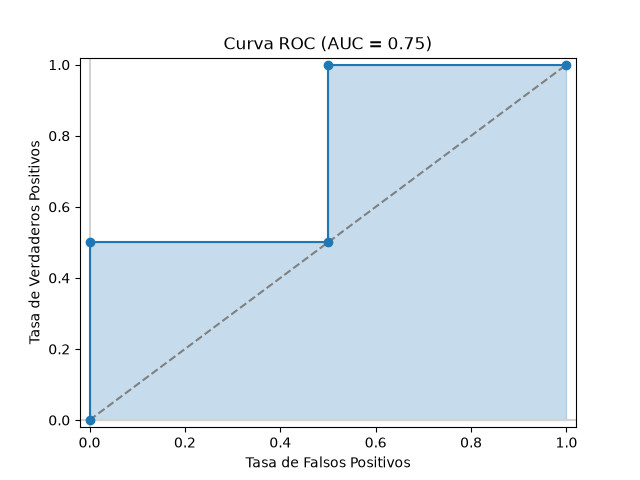

In [ ]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC (AUC = 0.75)')
ax.plot([0, 1], [0, 1], c='gray', linestyle='--')  # referencia: adivinar al azar (AUC=0.5)
ax.fill_between(xs, ys, color='C0', alpha=0.25)     # área bajo la curva = AUC
_ = ax.plot(xs, ys, c='C0', marker='o')


El área azul sombreada es, literalmente, la integral que hemos calculado con `auc(xs, ys)`: cada «escalón» de la curva corresponde a un umbral de decisión distinto, y por debajo de esa línea quedan $0{,}75$ unidades de área. La diagonal gris discontinua marca el «azar» ($\text{AUC}=0{,}5$) — cuanto más se aleje la curva azul de esa diagonal hacia la esquina superior izquierda, mejor separa el modelo las dos clases.

## Resumen: Lo Más Importante de Este Notebook

Una chuleta rápida con lo esencial de los 3 segmentos, para repasar sin releer todo el notebook.

### Derivadas parciales y el gradiente

* Una **derivada parcial** deriva una función de varias variables respecto a **una** de ellas, tratando las demás como constantes: $\frac{\partial z}{\partial x}$.
* El **gradiente** ($\nabla$) junta todas las derivadas parciales de una función en un vector — y apunta en la dirección en la que la función crece más rápido.
* Ejemplo: con $z=x^2-y^2$, $\frac{\partial z}{\partial x}=2x$ y $\frac{\partial z}{\partial y}=-2y$ (cada término «desaparece» al derivar respecto a la otra variable, por ser tratado como constante).

### Coste, descenso de gradiente y retropropagación

* La **función de coste** ($C=(\hat{y}-y)^2$) mide el error de un modelo, y depende de **todos** sus parámetros a la vez.
* **Descenso de gradiente**: mover cada parámetro en la dirección **opuesta** a su derivada parcial en $C$ ($w_{\text{nuevo}}=w_{\text{viejo}}-\eta\cdot\frac{\partial C}{\partial w}$) reduce el error paso a paso — así «aprende» un modelo.
* **Retropropagación**: aplicar la regla de la cadena (de *Cálculo I*) a derivadas parciales, capa por capa desde la salida hacia la entrada, calcula el gradiente completo de una red neuronal en una sola pasada.

**Ejemplo real** (red de 2 capas: $h=\sigma(w_1x+b_1)$, $\hat{y}=w_2h+b_2$): una sola llamada a `.backward()` da los 4 gradientes a la vez — incluido $\partial L/\partial w_1\approx-0{,}9478$, el de la capa más alejada de la salida, calculado encadenando 3 derivadas parciales ($\partial L/\partial\hat{y}\cdot\partial\hat{y}/\partial h\cdot\partial h/\partial w_1$) — la regla de la cadena en acción, exactamente igual con 2 capas que con 200.

Como grafo (igual que con la regresión lineal, pero con una capa extra en medio):

```
Capa oculta:
x ──────┐
        ×──┐
w1 ─────┘  │
           +──► pre₁ ──► σ ──► h
b1 ────────┘

Capa de salida:
h ──────┐
        ×──┐
w2 ─────┘  │
           +──► ŷ
b2 ────────┘

Coste:
ŷ ──────┐
        −──► (ŷ−y) ──► ^2 ──► L
y ──────┘
```

In [1]:
w1 = torch.tensor(0.5, requires_grad=True)   # peso de la capa oculta
b1 = torch.tensor(0.0, requires_grad=True)   # sesgo de la capa oculta
w2 = torch.tensor(1.5, requires_grad=True)   # peso de la capa de salida
b2 = torch.tensor(0.1, requires_grad=True)   # sesgo de la capa de salida
x = torch.tensor(2.0)                        # dato de entrada
y_true = torch.tensor(2.0)                   # valor real

h = torch.sigmoid(w1 * x + b1)   # forward pass: capa oculta (no lineal)
y_pred = w2 * h + b2             # forward pass: capa de salida
loss = (y_pred - y_true)**2      # forward pass: coste

loss.backward()                  # backward pass: los 4 gradientes a la vez

print(f"dL/dw1 = {w1.grad.item():.4f}  (capa oculta)")
print(f"dL/db1 = {b1.grad.item():.4f}  (capa oculta)")
print(f"dL/dw2 = {w2.grad.item():.4f}  (capa de salida)")
print(f"dL/db2 = {b2.grad.item():.4f}  (capa de salida)")


dL/dw1 = -0.9478  (capa oculta)
dL/db1 = -0.4739  (capa oculta)
dL/dw2 = -1.1747  (capa de salida)
dL/db2 = -1.6068  (capa de salida)


### Integrales

* Una **integral** calcula el área bajo una curva — la operación inversa de la derivada.
* Se puede resolver a mano con la **antiderivada** (la regla de la potencia «al revés»: sumar 1 al exponente y dividir por él), o numéricamente con `scipy.integrate.quad` (dividiendo el área en franjas estrechas y sumándolas, como el método delta pero para áreas).
* Ejemplo: $\int_1^2 \frac{x}{2}dx = 0{,}75$; $\int_3^4 2x\,dx = 7$.

### Clasificación binaria y la curva ROC

* En un problema de sí/no, la **matriz de confusión** recoge los 4 resultados posibles al comparar predicción y realidad: verdadero/falso positivo/negativo.
* La **curva ROC** representa la tasa de verdaderos positivos frente a la de falsos positivos, según se mueve el umbral de decisión.
* El **AUC** (área bajo esa curva, calculada con una integral) resume el rendimiento del clasificador en un solo número: $1$ = perfecto, $0{,}5$ = adivinar al azar.

**Ejemplo real**: con la curva ROC sencilla de 5 puntos del notebook, el área da $0{,}75$ — bastante mejor que adivinar al azar (diagonal gris), aunque lejos de ser un clasificador perfecto:

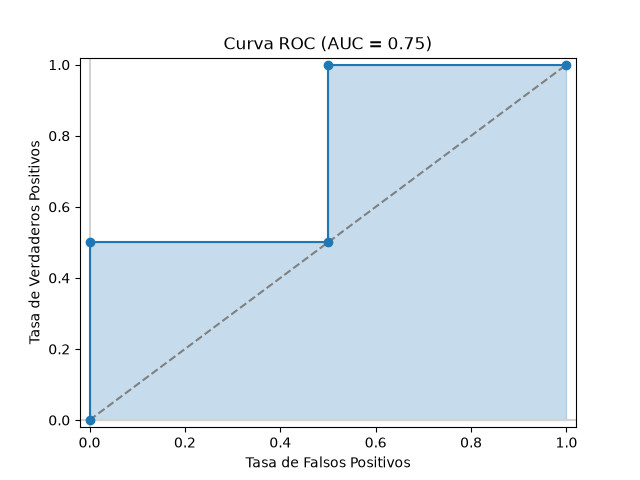